# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click !here goes the icon of the corresponding button in the gutter! button.
To debug a cell, press Alt+Shift+Enter, or click !here goes the icon of the corresponding button in the gutter! button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/jupyter-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [19]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('data/Processed_S&P.csv')
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

,Date,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,...,NZD,silver-F,RUSSELL-F,S&P-F,CHF,Dollar index-F,Dollar index,wheat-F,XAG,XAU
0,2009-12-31,1115.099976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.26,-1.08,-1.00,-0.11,-0.08,-0.06,-0.48,0.30,0.39
1,2010-01-04,1132.989990,0.921723,0.016043,NaN,NaN,NaN,NaN,NaN,NaN,...,1.52,3.26,1.61,1.62,-0.57,-0.59,-0.42,3.12,3.91,2.10
2,2010-01-05,1136.520020,-0.375903,0.003116,0.016043,NaN,NaN,NaN,NaN,NaN,...,-0.07,1.96,-0.20,0.31,0.43,0.03,0.12,-0.90,1.42,-0.12
3,2010-01-06,1137.140015,0.996234,0.000546,0.003116,0.016043,NaN,NaN,NaN,NaN,...,0.56,2.15,-0.02,0.07,-0.56,-0.24,-0.17,2.62,2.25,1.77
4,2010-01-07,1141.689941,0.059932,0.004001,0.000546,0.003116,0.016043,NaN,NaN,NaN,...,-0.72,0.94,0.50,0.40,0.58,0.58,0.54,-1.85,0.22,-0.58


In [21]:
# 2. Create current day's log return
df["log_ret"] = np.log(df["Close"]).diff()

# 3. Shift to make NEXT-day return the target
df["target"] = df["log_ret"].shift(-1)

df.head()

,Date,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,...,RUSSELL-F,S&P-F,CHF,Dollar index-F,Dollar index,wheat-F,XAG,XAU,log_ret,target
0,2009-12-31,1115.099976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.08,-1.00,-0.11,-0.08,-0.06,-0.48,0.30,0.39,NaN,0.015916
1,2010-01-04,1132.989990,0.921723,0.016043,NaN,NaN,NaN,NaN,NaN,NaN,...,1.61,1.62,-0.57,-0.59,-0.42,3.12,3.91,2.10,0.015916,0.003111
2,2010-01-05,1136.520020,-0.375903,0.003116,0.016043,NaN,NaN,NaN,NaN,NaN,...,-0.20,0.31,0.43,0.03,0.12,-0.90,1.42,-0.12,0.003111,0.000545
3,2010-01-06,1137.140015,0.996234,0.000546,0.003116,0.016043,NaN,NaN,NaN,NaN,...,-0.02,0.07,-0.56,-0.24,-0.17,2.62,2.25,1.77,0.000545,0.003993
4,2010-01-07,1141.689941,0.059932,0.004001,0.000546,0.003116,0.016043,NaN,NaN,NaN,...,0.50,0.40,0.58,0.58,0.54,-1.85,0.22,-0.58,0.003993,0.002878


Selected features: ['Close', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200', 'DE4', 'DE5']


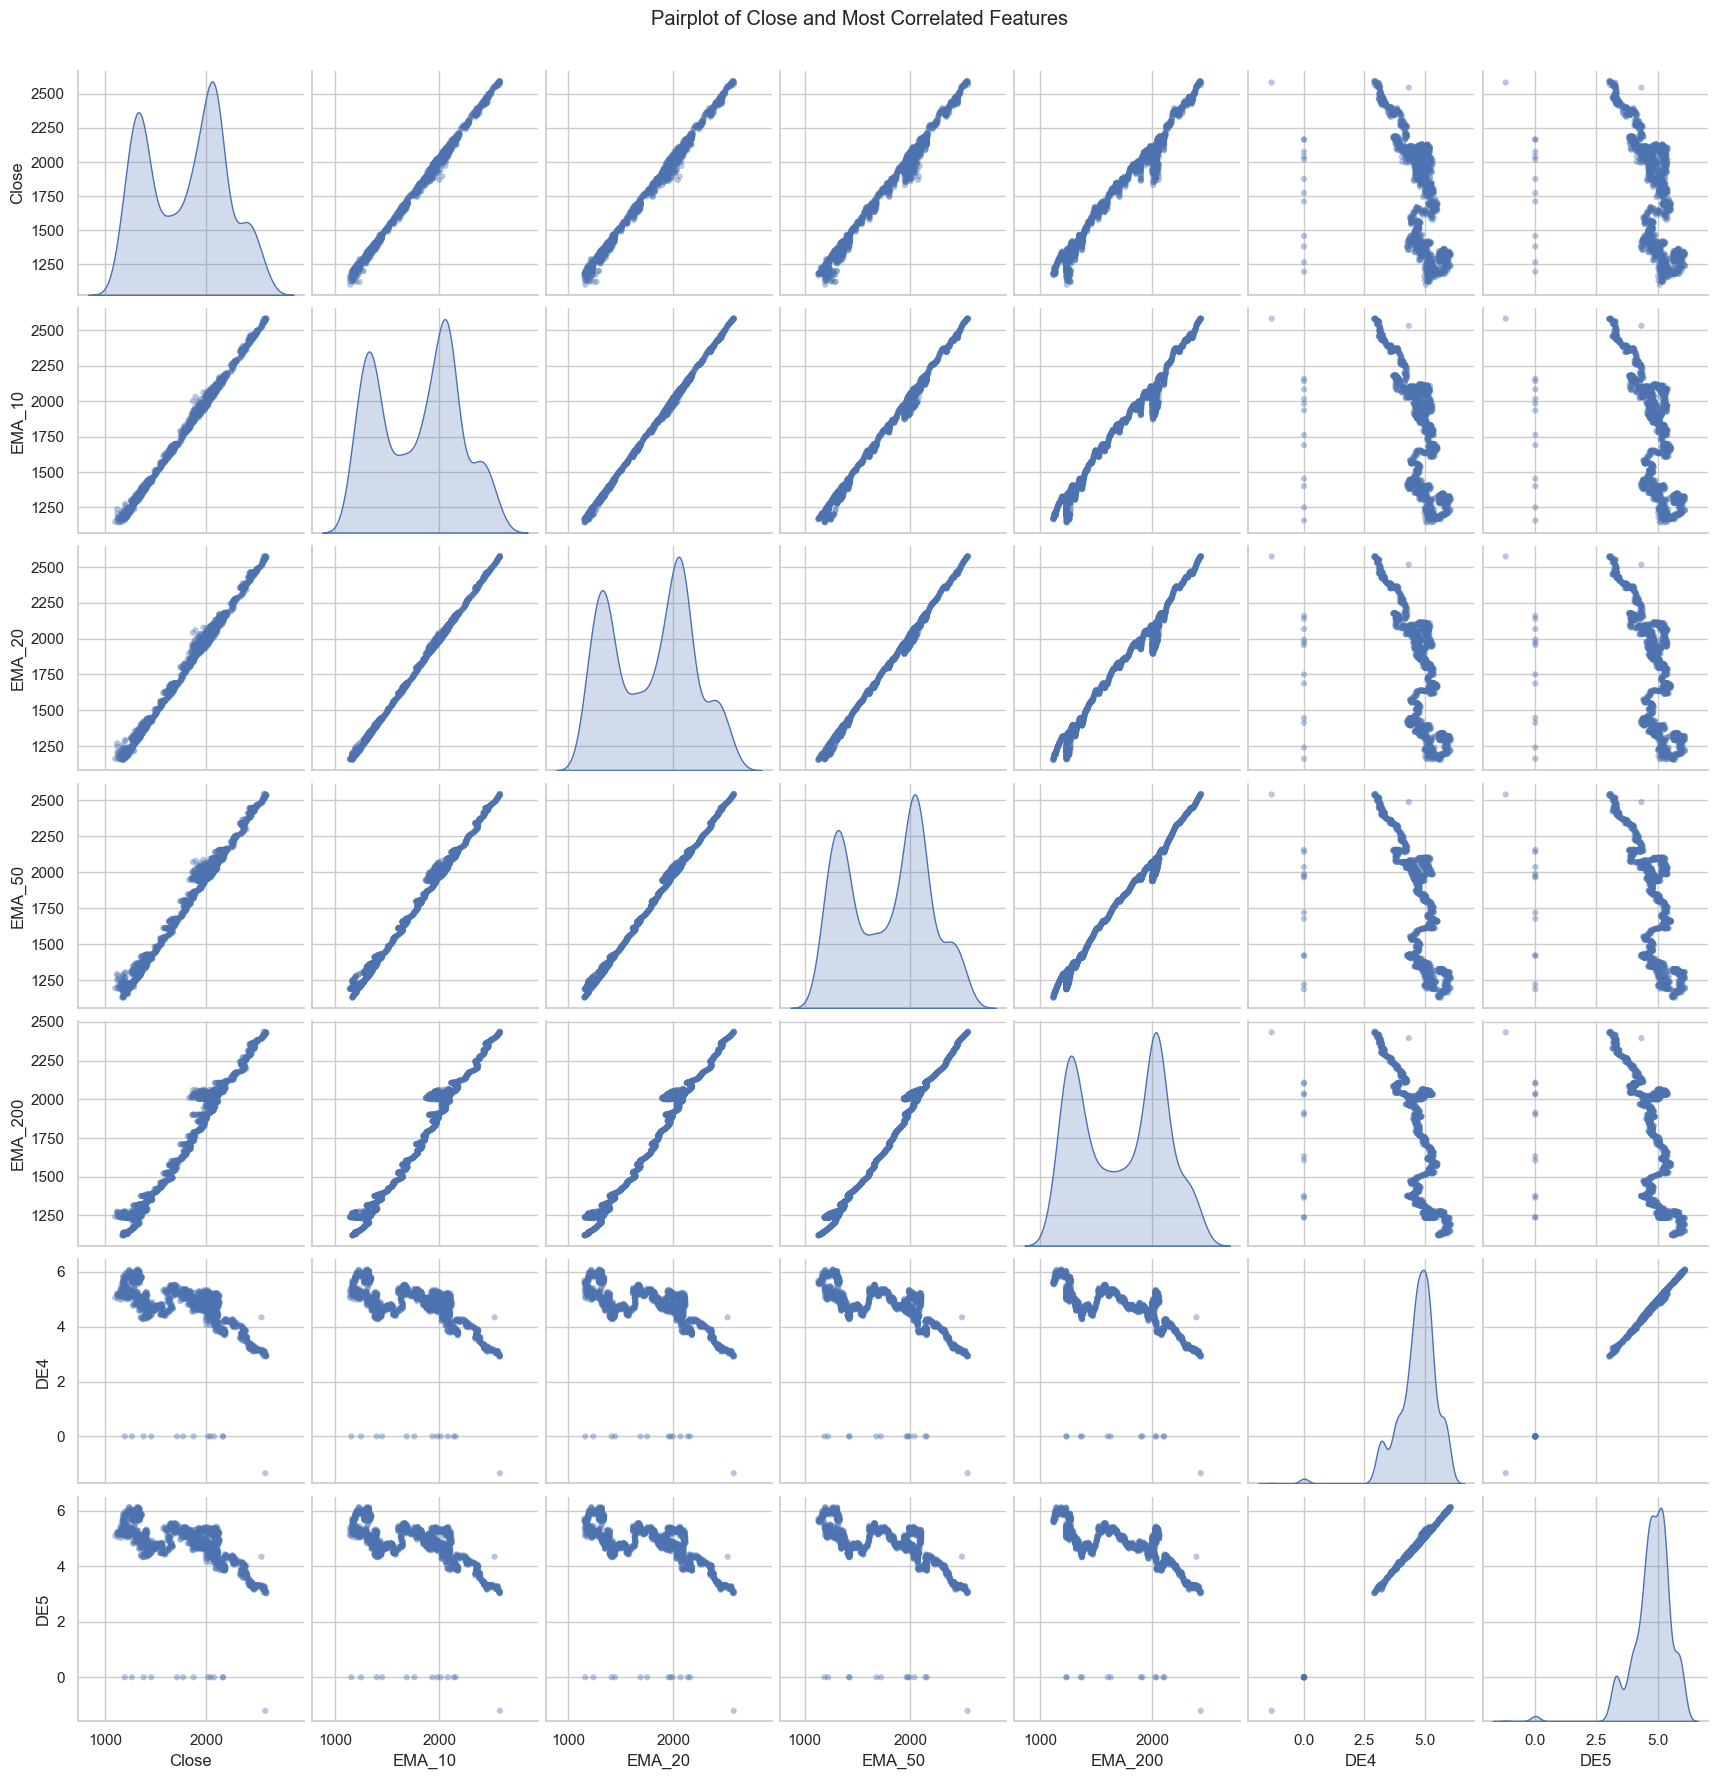

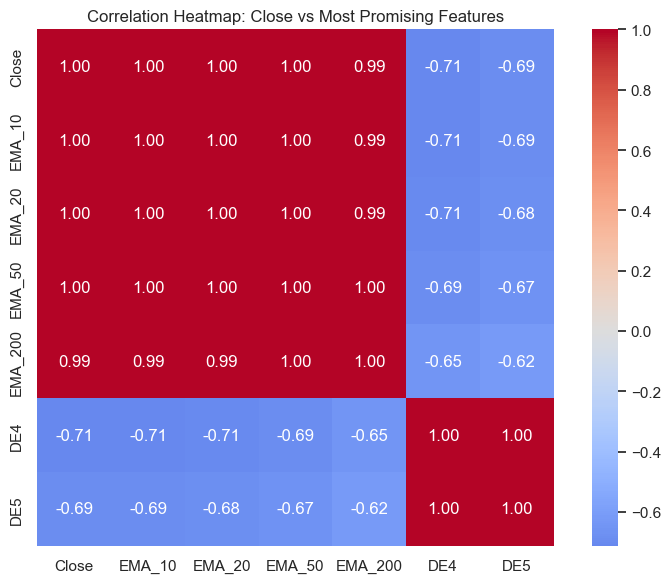

In [23]:
target_col = "Close"
num_df = df.select_dtypes(include="number")
# correlation with target
corr_with_target = num_df.corr(numeric_only=True)[target_col].dropna()

# drop the target itself and sort by absolute correlation
corr_with_target = corr_with_target.drop(labels=[target_col])
top_n = 6  # how many strongest features to keep
top_features = corr_with_target.abs().sort_values(ascending=False).head(top_n).index.tolist()

# final feature set for visualization
feat_cols = [target_col] + top_features
print("Selected features:", feat_cols)

# --- Seaborn pairplot ---
sns.set(style="whitegrid")
sns.pairplot(
    df[feat_cols].dropna(),
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 20, "edgecolor": "none"},
)
plt.suptitle("Pairplot of Close and Most Correlated Features", y=1.02)
plt.show()

# --- Correlation heatmap for those features ---
plt.figure(figsize=(8, 6))
corr_matrix = df[feat_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Correlation Heatmap: Close vs Most Promising Features")
plt.tight_layout()
plt.show()


Asset columns used for correlation: ['Close', 'Oil', 'Gold', 'DJI']


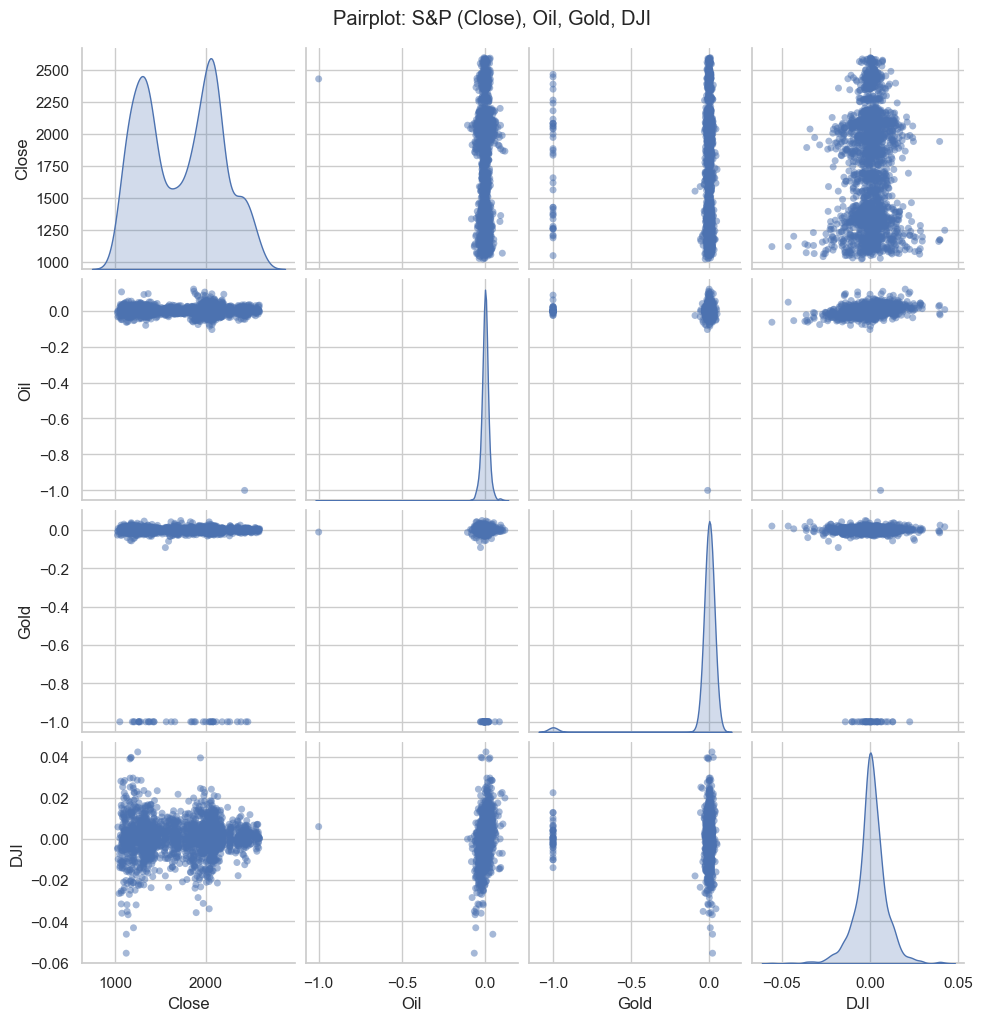

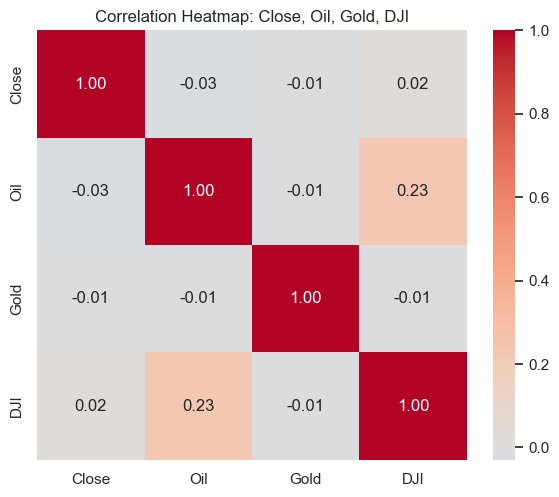

In [24]:
asset_cols = ["Close", "Oil", "Gold", "DJI"]

# keep only those that actually exist in the file
asset_cols = [c for c in asset_cols if c in df.columns]
print("Asset columns used for correlation:", asset_cols)

# Pairplot for these assets
sns.pairplot(
    df[asset_cols].dropna(),
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 25, "edgecolor": "none"},
)
plt.suptitle("Pairplot: S&P (Close), Oil, Gold, DJI", y=1.02)
plt.show()

# Correlation heatmap for these assets
plt.figure(figsize=(6, 5))
asset_corr = df[asset_cols].corr()
sns.heatmap(
    asset_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Correlation Heatmap: Close, Oil, Gold, DJI")
plt.tight_layout()
plt.show()

In [7]:
df_model = df.dropna().copy()

# Features (X) and target (y)
X = df_model.drop(columns=["Date", "target", "Name"])
y = df_model["target"]

print(X.shape, y.shape)

(1114, 83) (1114,)


In [8]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R^2:", r2)

MSE: 5.355904463522336e-05
R^2: -0.47122942924954847


In [10]:
direction_acc = (np.sign(y_pred) == np.sign(y_test)).mean()
print("Directional accuracy:", direction_acc)

Directional accuracy: 0.515695067264574


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns) \
               .sort_values(ascending=False)

print(importances.head(15))

ROC_5      0.037253
ROC_10     0.035535
ROC_20     0.033636
mom1       0.030672
mom2       0.027051
KOSPI-F    0.025855
mom3       0.025245
ROC_15     0.025225
CTB3M      0.023746
Gold       0.022135
Volume     0.018527
AMZN       0.018149
Close      0.016710
wheat-F    0.016373
JPM        0.016071
dtype: float64


In [13]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [200, 300, 400, 500, 600, 700, 800, 900, 1000],
    "max_depth": [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)

Fitting 5 folds for each of 1872 candidates, totalling 9360 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=   0.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=400; total time=   2.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=700; total time=   1.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=800; total time=   4.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=300; total time=   0.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=400; total time=   1.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=600; total time=   0.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=700; total time=   1.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=800; total time=   1.6s
[CV] END max_depth=None, m

In [15]:
print("Best CV score (neg MSE):", grid_search.best_score_)

Best CV score (neg MSE): -8.62893669662754e-05
